In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import warnings
warnings.filterwarnings('ignore')

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference,
    selection_rate
)
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [2]:
xgb_model     = joblib.load('../models/xgboost_model.pkl')
feature_names = joblib.load('../models/feature_names.pkl')

X_test = pd.read_csv('../data/X_test.csv').reset_index(drop=True)
y_test = pd.read_csv('../data/y_test.csv').squeeze().reset_index(drop=True)

# Load original data to get raw sensitive feature values
df_original = pd.read_csv('../data/telco_churn.csv')
df_original['TotalCharges'] = pd.to_numeric(df_original['TotalCharges'], errors='coerce')
df_original.dropna(inplace=True)
df_original.reset_index(drop=True, inplace=True)

y_pred = xgb_model.predict(X_test)

print(f"Test set: {X_test.shape}")
print(f"Predictions — Churn: {y_pred.sum()}, No Churn: {(y_pred==0).sum()}")

Test set: (1407, 19)
Predictions — Churn: 317, No Churn: 1090


In [3]:
# We need to match the test indices back to original data
# Recreate the same train/test split to get correct indices
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = df_original.copy()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.drop('customerID', axis=1, inplace=True)

cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

_, X_test_check, _, y_test_check = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Get sensitive features aligned to test set
sensitive_features_raw = df_original.loc[X_test_check.index].reset_index(drop=True)

gender     = sensitive_features_raw['gender']
senior     = sensitive_features_raw['SeniorCitizen'].map({0: 'Non-Senior', 1: 'Senior'})
contract   = sensitive_features_raw['Contract']

print("Sensitive features extracted ✓")
print(f"Gender distribution:\n{gender.value_counts()}")
print(f"\nSenior distribution:\n{senior.value_counts()}")
print(f"\nContract distribution:\n{contract.value_counts()}")

Sensitive features extracted ✓
Gender distribution:
gender
Male      726
Female    681
Name: count, dtype: int64

Senior distribution:
SeniorCitizen
Non-Senior    1175
Senior         232
Name: count, dtype: int64

Contract distribution:
Contract
Month-to-month    790
Two year          327
One year          290
Name: count, dtype: int64


In [4]:
# Demographic Parity: are churn predictions equal across genders?
dpd_gender = demographic_parity_difference(
    y_true              = y_test,
    y_pred              = y_pred,
    sensitive_features  = gender
)

print("=== Demographic Parity (Gender) ===")
print(f"Difference: {dpd_gender:.4f}")
print("(0.0 = perfectly fair, >0.1 = concerning)")

# Selection rate per gender
mf_gender = MetricFrame(
    metrics            = selection_rate,
    y_true             = y_test,
    y_pred             = y_pred,
    sensitive_features = gender
)
print(f"\nChurn prediction rate by gender:")
print(mf_gender.by_group)

=== Demographic Parity (Gender) ===
Difference: 0.0301
(0.0 = perfectly fair, >0.1 = concerning)

Churn prediction rate by gender:
gender
Female    0.240822
Male      0.210744
Name: selection_rate, dtype: float64


In [5]:
dpd_senior = demographic_parity_difference(
    y_true             = y_test,
    y_pred             = y_pred,
    sensitive_features = senior
)

print("=== Demographic Parity (Senior Citizen) ===")
print(f"Difference: {dpd_senior:.4f}")

mf_senior = MetricFrame(
    metrics            = selection_rate,
    y_true             = y_test,
    y_pred             = y_pred,
    sensitive_features = senior
)
print(f"\nChurn prediction rate by senior status:")
print(mf_senior.by_group)

=== Demographic Parity (Senior Citizen) ===
Difference: 0.2309

Churn prediction rate by senior status:
SeniorCitizen
Non-Senior    0.187234
Senior        0.418103
Name: selection_rate, dtype: float64


In [6]:
# Equalized odds: are TPR and FPR equal across groups?
eod_senior = equalized_odds_difference(
    y_true             = y_test,
    y_pred             = y_pred,
    sensitive_features = senior
)

print("=== Equalized Odds (Senior Citizen) ===")
print(f"Difference: {eod_senior:.4f}")
print("(0.0 = perfectly fair, >0.1 = model treats groups differently)")

=== Equalized Odds (Senior Citizen) ===
Difference: 0.1722
(0.0 = perfectly fair, >0.1 = model treats groups differently)


In [7]:
metrics = {
    'accuracy'  : accuracy_score,
    'precision' : lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
    'recall'    : lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
    'selection_rate': selection_rate
}

mf_full = MetricFrame(
    metrics            = metrics,
    y_true             = y_test,
    y_pred             = y_pred,
    sensitive_features = senior
)

print("=== Full Metrics by Senior Status ===")
print(mf_full.by_group.round(3))
print(f"\nOverall metrics:")
print(mf_full.overall.round(3))

=== Full Metrics by Senior Status ===
               accuracy  precision  recall  selection_rate
SeniorCitizen                                             
Non-Senior        0.809      0.623   0.493           0.187
Senior            0.694      0.629   0.635           0.418

Overall metrics:
accuracy          0.790
precision         0.625
recall            0.529
selection_rate    0.225
dtype: float64


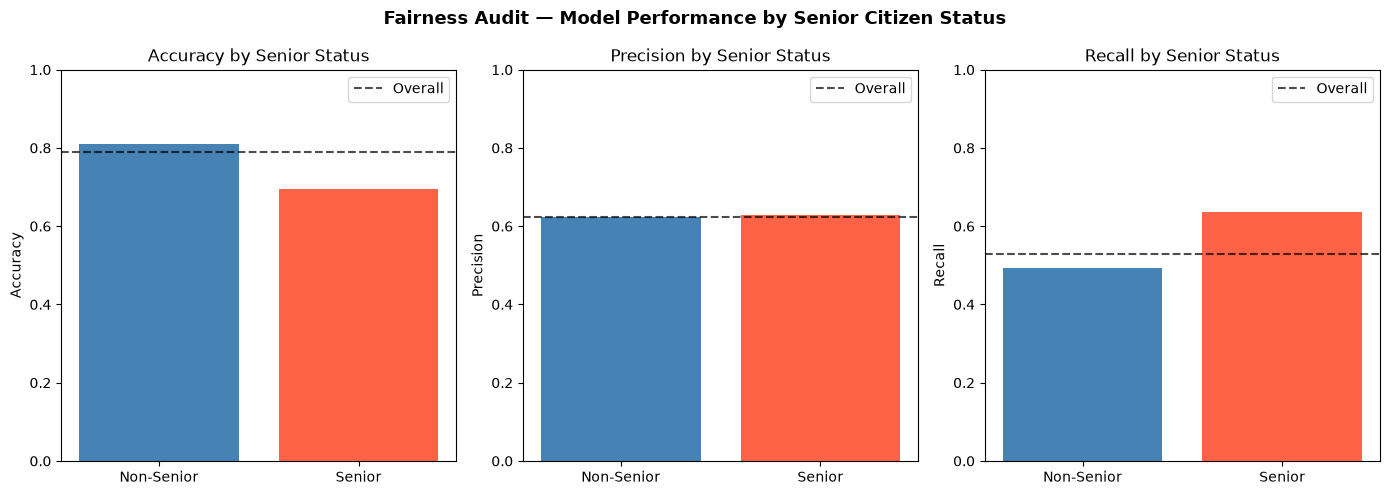

In [8]:
by_group = mf_full.by_group.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_to_plot = ['accuracy', 'precision', 'recall']
colors = ['steelblue', 'tomato']

for i, metric in enumerate(metrics_to_plot):
    axes[i].bar(
        by_group['SeniorCitizen'],
        by_group[metric],
        color=colors
    )
    axes[i].set_title(f'{metric.capitalize()} by Senior Status')
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel(metric.capitalize())
    axes[i].axhline(
        y    = mf_full.overall[metric],
        color = 'black',
        linestyle = '--',
        alpha = 0.7,
        label = 'Overall'
    )
    axes[i].legend()

plt.suptitle('Fairness Audit — Model Performance by Senior Citizen Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fairness_by_senior.png', dpi=150, bbox_inches='tight')
plt.show()

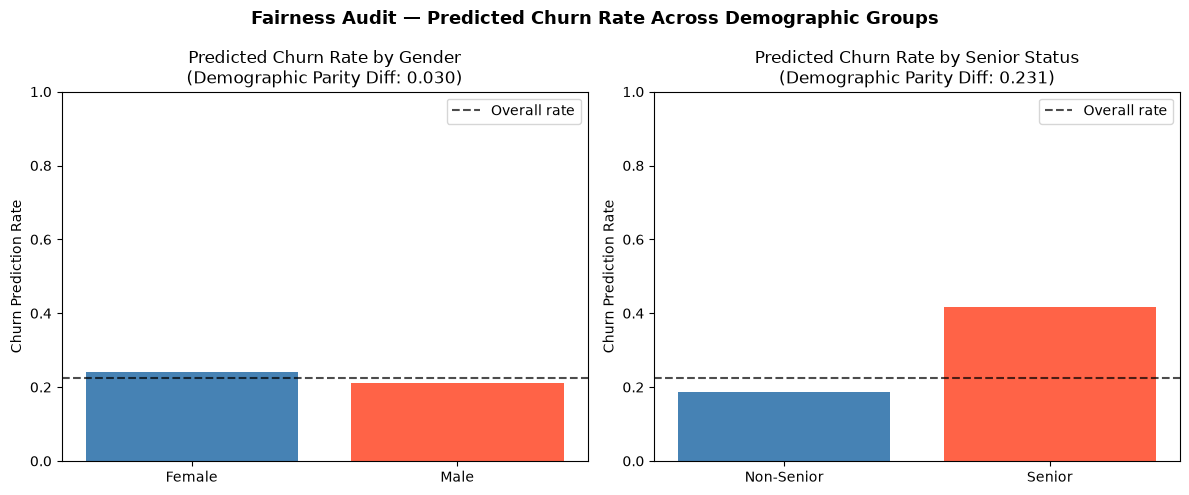

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gender
gender_rates = mf_gender.by_group.reset_index()
gender_rates.columns = ['Group', 'Churn Rate']
axes[0].bar(gender_rates['Group'], gender_rates['Churn Rate'],
            color=['steelblue', 'tomato'])
axes[0].set_title(f'Predicted Churn Rate by Gender\n(Demographic Parity Diff: {dpd_gender:.3f})')
axes[0].set_ylabel('Churn Prediction Rate')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=y_pred.mean(), color='black', linestyle='--',
                alpha=0.7, label='Overall rate')
axes[0].legend()

# Senior
senior_rates = mf_senior.by_group.reset_index()
senior_rates.columns = ['Group', 'Churn Rate']
axes[1].bar(senior_rates['Group'], senior_rates['Churn Rate'],
            color=['steelblue', 'tomato'])
axes[1].set_title(f'Predicted Churn Rate by Senior Status\n(Demographic Parity Diff: {dpd_senior:.3f})')
axes[1].set_ylabel('Churn Prediction Rate')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=y_pred.mean(), color='black', linestyle='--',
                alpha=0.7, label='Overall rate')
axes[1].legend()

plt.suptitle('Fairness Audit — Predicted Churn Rate Across Demographic Groups',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fairness_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
fairness_summary = {
    'demographic_parity_gender' : round(dpd_gender, 4),
    'demographic_parity_senior' : round(dpd_senior, 4),
    'equalized_odds_senior'     : round(eod_senior, 4),
    'overall_accuracy'          : round(mf_full.overall['accuracy'], 4),
    'overall_precision'         : round(mf_full.overall['precision'], 4),
    'overall_recall'            : round(mf_full.overall['recall'], 4),
}

pd.DataFrame([fairness_summary]).to_csv('../data/fairness_summary.csv', index=False)
joblib.dump(fairness_summary, '../models/fairness_summary.pkl')

print("Fairness summary saved ✓")
for k, v in fairness_summary.items():
    print(f"  {k}: {v}")

Fairness summary saved ✓
  demographic_parity_gender: 0.0301
  demographic_parity_senior: 0.2309
  equalized_odds_senior: 0.1722
  overall_accuracy: 0.7903
  overall_precision: 0.6246
  overall_recall: 0.5294
